In [14]:
import pandas as pd

# Load the CSV
df = pd.read_csv("../data/raw_analyst_ratings.csv")

# Convert the 'date' column to datetime safely
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

# Display first few rows
df.head()



C:\Users\hp\AppData\Local\Temp\ipykernel_8248\1162888945.py:7: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [15]:
df['headline_length'] = df['headline'].astype(str).apply(len)

print("Headline Length Stats:")
print(df['headline_length'].describe())



Headline Length Stats:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


Top Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


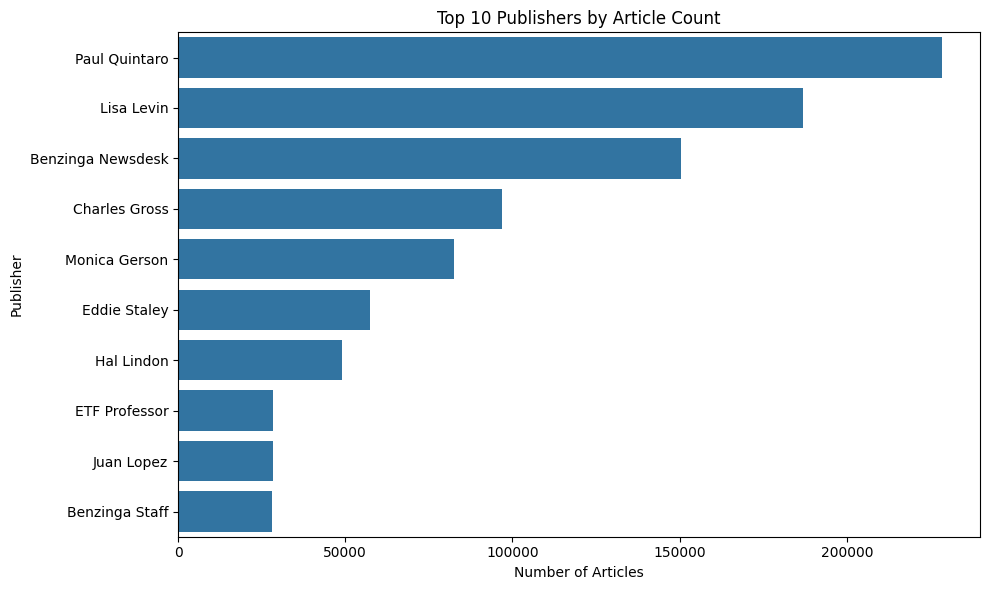

In [19]:
publisher_counts = df['publisher'].value_counts()

print("Top Publishers:")
print(publisher_counts.head(10))

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=publisher_counts.head(10).values, y=publisher_counts.head(10).index)
plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")
plt.tight_layout()
plt.show()


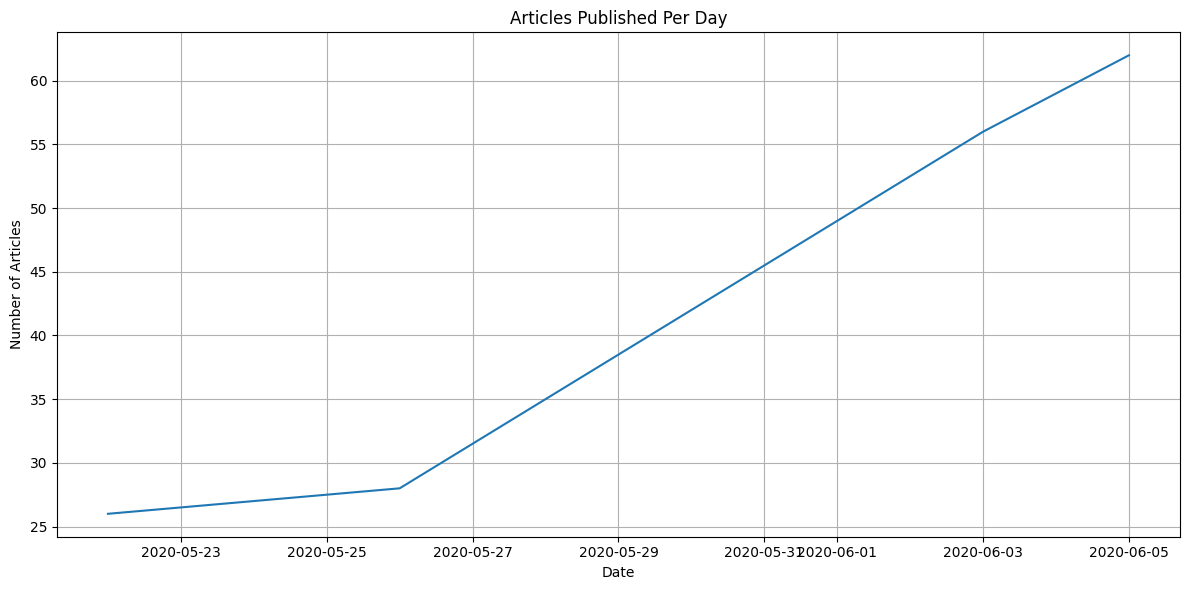

In [21]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['date_only'] = df['date'].dt.date

articles_per_day = df.groupby('date_only').size()

plt.figure(figsize=(12, 6))
articles_per_day.plot()
plt.title("Articles Published Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.tight_layout()
plt.show()


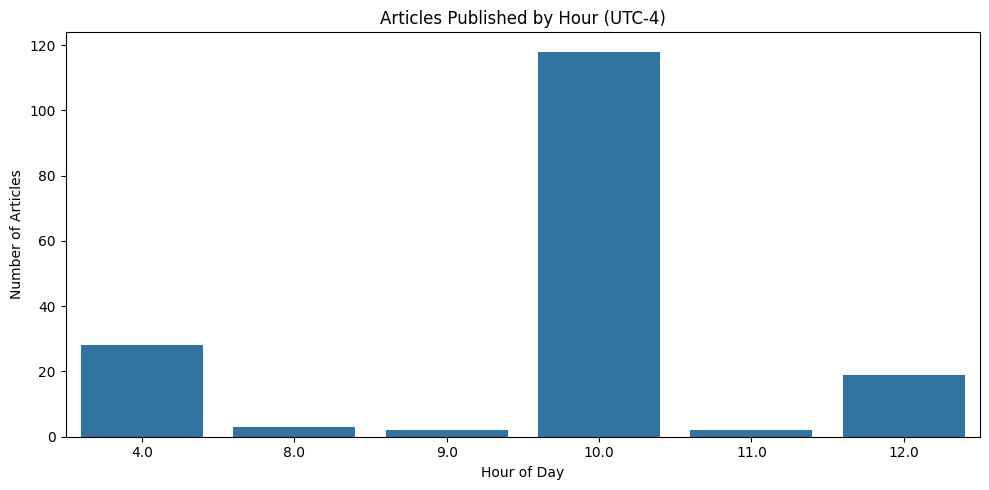

In [22]:
df['hour'] = df['date'].dt.hour

hourly_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title("Articles Published by Hour (UTC-4)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()


In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# Use 'headline' column
texts = df['headline'].dropna().tolist()

# Vectorize the headlines
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(texts)

# Apply LDA (using 5 topics here)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Show top 10 words per topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"\n🧠 Topic {topic_idx + 1}:")
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [words[i] for i in top_words_idx]
    print("  ", ", ".join(top_words))



🧠 Topic 1:
   earnings, stocks, benzinga, scheduled, etfs, watch, etf, 2018, 2019, 10

🧠 Topic 2:
   shares, trading, stocks, says, companies, higher, week, stock, lower, 52

🧠 Topic 3:
   vs, est, eps, reports, sales, pt, buy, raises, maintains, target

🧠 Topic 4:
   new, stocks, announces, week, 52, reports, industry, set, highest, low

🧠 Topic 5:
   market, mid, stocks, update, session, moving, day, benzinga, biggest, downgrades


In [33]:
df['publisher_domain'] = df['publisher'].str.extract(r'@([a-zA-Z0-9.-]+)')
domain_counts = df['publisher_domain'].value_counts()

print("Top Publisher Domains:")
print(domain_counts.head(10))


Top Publisher Domains:
publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64
